<a href="https://colab.research.google.com/github/ByungChul-Cha/Deep_Learning_Study/blob/main/Day07/11_%ED%85%8D%EC%8A%A4%ED%8A%B8%EC%9D%98_%EC%9C%A0%EC%82%AC%EB%8F%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **11-01. 단어의 표현 방법**

# 단어의 표현 방법
- 국소 표현(Local Representation)
  - 단어 그 자체만 보고, 특정값을 맵하여 단어를 표현하는 방법
  - 단어의 의미, 뉘앙스 표현 X
  - 이산 표현(Discrete Representation)이라고도 함
  - DTM(TDM), TF-IDF
- 분산 표현(Distributed Representation)
  - 단어를 표현하고자 주변을 참고하여 단어를 표현하는 방법
  - 단어의 의미, 뉘앙스 표현 O
  - 연속 표현(Continuous Representation)이라고도 함
  - Word2Vec, FastText, GloVe

# **11-02. Bag of Words 방법**

# Bag of Words란?
- 단어들의 순서는 고려하지 않고, 출현 빈도에만 집중하는 텍스트 데이터의 수치화 표현 방법
- 문서가 어떤 성격의 문서인지를 판단하는 작업에 쓰임
- 분류 문제, 여러 문서 간의 유사도를 구하는 문제
- 텍스트 내에서 어떤 단어들이 중요한지를 의미

# **11-03. DTM과 TF-IDF 행렬**

# 문서 단어 행렬(Documnet-Term Matrix, DTM)의 표기법
- 다수의 문서에서 등장하는 각 단어들의 빈도를 행렬로 표현
- 문서들을 서로 비교할 수 있도록 수치화할 수 있음

# DTM의 한계
- 희소 표현
  - 공간적 낭비와 계산 리소스를 증가시킴
  - 희소 벡터, 희소 행렬:
    - 대부분의 값이 0인 표현
    - 많은 양의 저장 공간과 높은 계산 복잡도 요구
- 단순 빈도 수 기반 접근
  - 불용어가 많이 나옴 -> 유사한 문서가 아닐 확률이 높음
  - DTM에 불용어와 중요한 단어에 대해서 가중치 반영 -> TF-IDF 사용

# TF-IDF(단어 빈도-역 문서 빈도, Term Frequency-Inverse Document Frequency)
- 단어의 빈도와 역문서 빈도를 사용하여 DTM 내의 각 단어들마다 중요한 정도를 가중치로 주는 방법
- 문서의 유사도, 검색 결과의 중요도를 정하는 작업, 특정 단어의 중요도를 구하는 작업
- 문서: d, 단어: t, 문서의 총 개수: n
  - tf(d,t): 특정 문서 d에서의 특정 단어 t의 등장 횟수
  - df(t): 특정 단어 t가 등장한 문서의 수
  - idf(t): df(t)에 반비례하는 수
    - idf(t) = log(n/(1+df(t)))
    - log를 통해 가중치 부여의 격차 줄이기
    - 여러 문서에서 등장한 단어의 가중치를 낮추는 역할
  - 최종: tf * idf
- TF-IDF 값이 클 수록 중요도가 큼

In [7]:
import pandas as pd
from math import log

docs = [
    '먹고 싶은 사과',
    '먹고 싶은 바나나',
    '길고 노란 바나나 바나나',
    '저는 과일이 좋아요'
]
vocab = list(set(w for doc in docs for w in doc.split()))
vocab.sort()

In [8]:
N = len(docs)

def tf(t, d):
  return d.count(t)

def idf(t):
  df = 0
  for doc in docs:
    df += t in doc
  return log(N/(df+1))

def tfidf(t, d):
  return tf(t, d)*idf(t)

In [9]:
result = []

for i in range(N):
  result.append([])
  d = docs[i]
  for j in range(len(vocab)):
    t = vocab[j]
    result[-1].append(tf(t, d))

tf_ = pd.DataFrame(result, columns = vocab)
tf_

,과일이,길고,노란,먹고,바나나,사과,싶은,저는,좋아요
0,0,0,0,1,0,1,1,0,0
1,0,0,0,1,1,0,1,0,0
2,0,1,1,0,2,0,0,0,0
3,1,0,0,0,0,0,0,1,1


In [10]:
result = []
for j in range(len(vocab)):
  t = vocab[j]
  result.append(idf(t))

idf_ = pd.DataFrame(result, index=vocab, columns=["IDF"])
idf_

,IDF
과일이,0.693147
길고,0.693147
노란,0.693147
먹고,0.287682
바나나,0.287682
사과,0.693147
싶은,0.287682
저는,0.693147
좋아요,0.693147


In [11]:
result = []
for i in range(N):
  result.append([])
  d = docs[i]
  for j in range(len(vocab)):
    t = vocab[j]
    result[-1].append(tfidf(t, d))
tfidf_ = pd.DataFrame(result, columns=vocab)
tfidf_

,과일이,길고,노란,먹고,바나나,사과,싶은,저는,좋아요
0,0.000000,0.000000,0.000000,0.287682,0.000000,0.693147,0.287682,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.287682,0.287682,0.000000,0.287682,0.000000,0.000000
2,0.000000,0.693147,0.693147,0.000000,0.575364,0.000000,0.000000,0.000000,0.000000
3,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147


# **11-04. 코사인 유사도를 이용한 추천 시스템**

# 코사인 유사도(Cosine Similarity)
- 두 벡터 간의 코사인 각도를 이용하여 구할 수 있는 두 벡터의 유사도
  - 방향이 완전히 동일: 1
  - 90°의 각을 이루면: 0
  - 180°의 각을 이루면: -1
- -1 이상 1 이하의 값을 가지며, 1에 가까울 수록 유사도가 높다고 판단
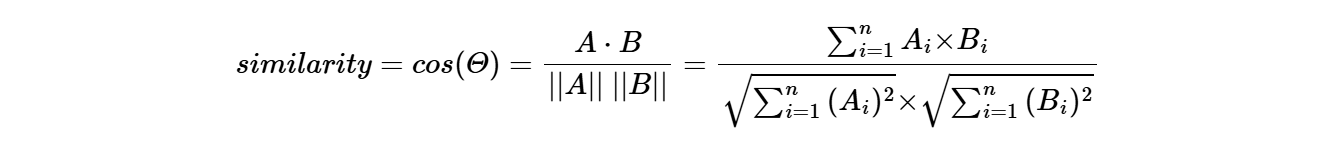

# **11-05. 단어와 문서의 유사도를 구하는 다양한 방법**
1. 코사인 유사도
2. 유클리드 거리(Euclidean distance)
  - 두 점 사이의 거리를 계산
  - 거리의 값이 작을 수록 유사함.
3. 자카드 유사도(Jaccard similarity)
  - 합집합에서 교집합의 비율을 구하는 방법
  - 0과 1사이의 값을 가짐